In [1]:
# ── Cell 1: Granular Aggregate Feature Extraction ────────────────────────────
import numpy as np
import pandas as pd

df = pd.read_csv("spatial_seer_all_rooms.csv")

CHANNELS = [
    "GpuUtil", "CpuUtil", "FrameTimeStdDev", "WorstFrameMs", "BestFrameMs",
    "MainThreadMs", "AvgFPS", "TotalUsedMem", "CpuClockFreq",
    "BatteryMicroAmps", "BatteryTemp", "GCAllocRate",
]
META_COLS = ["scan_id", "room_label", "location", "noise_type", "device_id"]

# Percentiles: every 5th percentile from 5 to 95 (19 values per channel just from percentiles)
PERCENTILES = list(range(5, 100, 5))

# Decile-window statistics: split each scan into 10 equal chunks, compute stats per chunk
N_DECILE_WINDOWS = 10

# Quartile-window statistics: split each scan into 4 equal chunks
N_QUARTILE_WINDOWS = 4

# Halves: first vs second half
N_HALVES = 2


def extract_features(values: np.ndarray, prefix: str) -> dict:
    """Extract ~80 statistical features from a 1-D signal."""
    feats = {}
    v = values[~np.isnan(values)]
    if len(v) == 0:
        return feats

    # Basic stats
    feats[f"{prefix}_mean"]   = v.mean()
    feats[f"{prefix}_std"]    = v.std()
    feats[f"{prefix}_var"]    = v.var()
    feats[f"{prefix}_min"]    = v.min()
    feats[f"{prefix}_max"]    = v.max()
    feats[f"{prefix}_median"] = np.median(v)
    feats[f"{prefix}_range"]  = v.max() - v.min()
    feats[f"{prefix}_sum"]    = v.sum()
    feats[f"{prefix}_abs_mean"] = np.abs(v).mean()
    feats[f"{prefix}_abs_sum"]  = np.abs(v).sum()
    feats[f"{prefix}_rms"]    = np.sqrt(np.mean(v ** 2))
    feats[f"{prefix}_energy"] = np.sum(v ** 2)

    # Percentiles (every 5%)
    for p in PERCENTILES:
        feats[f"{prefix}_p{p:02d}"] = np.percentile(v, p)
    feats[f"{prefix}_iqr"]  = np.percentile(v, 75) - np.percentile(v, 25)
    feats[f"{prefix}_idr"]  = np.percentile(v, 90) - np.percentile(v, 10)  # inter-decile range

    # Shape
    feats[f"{prefix}_skew"]     = pd.Series(v).skew()
    feats[f"{prefix}_kurtosis"] = pd.Series(v).kurtosis()
    feats[f"{prefix}_cv"]       = v.std() / abs(v.mean()) if v.mean() != 0 else 0
    feats[f"{prefix}_mad"]      = np.mean(np.abs(v - v.mean()))   # mean absolute deviation

    # Endpoints & trend
    feats[f"{prefix}_first"]  = v[0]
    feats[f"{prefix}_last"]   = v[-1]
    feats[f"{prefix}_diff_first_last"] = v[-1] - v[0]
    feats[f"{prefix}_ratio_first_last"] = v[-1] / v[0] if v[0] != 0 else 0
    if len(v) > 1:
        x = np.arange(len(v))
        slope, intercept = np.polyfit(x, v, 1)
        feats[f"{prefix}_trend"]     = slope
        feats[f"{prefix}_intercept"] = intercept
        # Residuals from linear fit — how non-linear is the signal
        residuals = v - (slope * x + intercept)
        feats[f"{prefix}_resid_std"] = residuals.std()
    else:
        feats[f"{prefix}_trend"] = 0
        feats[f"{prefix}_intercept"] = v[0] if len(v) else 0
        feats[f"{prefix}_resid_std"] = 0

    # Differenced signal (velocity)
    if len(v) > 1:
        d = np.diff(v)
        feats[f"{prefix}_diff_mean"]     = d.mean()
        feats[f"{prefix}_diff_std"]      = d.std()
        feats[f"{prefix}_diff_abs_mean"] = np.abs(d).mean()
        feats[f"{prefix}_diff_max"]      = d.max()
        feats[f"{prefix}_diff_min"]      = d.min()
        # Second-order (acceleration)
        if len(d) > 1:
            d2 = np.diff(d)
            feats[f"{prefix}_diff2_std"] = d2.std()
            feats[f"{prefix}_diff2_abs_mean"] = np.abs(d2).mean()
        # Direction changes
        sign_changes = np.sum(np.diff(np.sign(d)) != 0)
        feats[f"{prefix}_num_changes"] = sign_changes
        feats[f"{prefix}_pct_increasing"] = np.mean(d > 0)
        feats[f"{prefix}_pct_decreasing"] = np.mean(d < 0)

    # Rolling-window stats
    s = pd.Series(v)
    for w in [5, 10, 20]:
        if len(v) >= w:
            feats[f"{prefix}_roll{w}_std_mean"]  = s.rolling(w).std().mean()
            feats[f"{prefix}_roll{w}_mean_std"]  = s.rolling(w).mean().std()
            feats[f"{prefix}_roll{w}_max_max"]   = s.rolling(w).max().max()

    # Crossings around the mean — proxy for signal complexity
    mean_val = v.mean()
    feats[f"{prefix}_mean_crossings"] = np.sum(np.diff(np.sign(v - mean_val)) != 0)

    # Zone windows: halves, quartiles, deciles — stats within each chunk
    for n_windows, tag in [(N_HALVES, "half"), (N_QUARTILE_WINDOWS, "q"), (N_DECILE_WINDOWS, "d")]:
        chunks = np.array_split(v, n_windows)
        for i, chunk in enumerate(chunks):
            if len(chunk) == 0:
                continue
            feats[f"{prefix}_{tag}{i}_mean"] = chunk.mean()
            feats[f"{prefix}_{tag}{i}_std"]  = chunk.std()
            feats[f"{prefix}_{tag}{i}_max"]  = chunk.max()
            feats[f"{prefix}_{tag}{i}_min"]  = chunk.min()

    # Cross-chunk deltas: change between consecutive deciles captures drift patterns
    decile_means = [c.mean() for c in np.array_split(v, N_DECILE_WINDOWS) if len(c) > 0]
    for i in range(1, len(decile_means)):
        feats[f"{prefix}_d{i}_minus_d{i-1}_mean"] = decile_means[i] - decile_means[i-1]
    feats[f"{prefix}_decile_mean_std"] = np.std(decile_means)
    feats[f"{prefix}_decile_mean_range"] = max(decile_means) - min(decile_means)

    return feats


def aggregate_scan(scan_df: pd.DataFrame) -> dict:
    feats = {}
    for ch in CHANNELS:
        feats.update(extract_features(scan_df[ch].values, ch))
    # Cross-channel ratios: interesting side-channel combos
    gpu = scan_df["GpuUtil"].values
    cpu = scan_df["CpuUtil"].values
    if len(gpu) and len(cpu):
        ratio = gpu / (cpu + 1e-9)
        feats.update(extract_features(ratio, "GpuCpuRatio"))
    return feats


# Build feature matrix
rows = []
for scan_id, group in df.groupby("scan_id"):
    group = group.sort_values("Timestamp")
    meta = group.iloc[0][META_COLS[1:]].to_dict()
    feats = aggregate_scan(group)
    feats["scan_id"] = scan_id
    feats.update(meta)
    rows.append(feats)

features_df = pd.DataFrame(rows)

# Reorder so metadata is up front
meta_first = META_COLS + [c for c in features_df.columns if c not in META_COLS]
features_df = features_df[meta_first]

# Replace inf / NaN from divisions
features_df = features_df.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Feature matrix shape: {features_df.shape}")
print(f"Number of aggregate features: {features_df.shape[1] - len(META_COLS)}")
print(f"\nFeature-name sample:")
print(list(features_df.columns[5:25]))

features_df.to_csv("spatial_seer_features.csv", index=False)
print("\nSaved to spatial_seer_features.csv")

Feature matrix shape: (102, 1812)
Number of aggregate features: 1807

Feature-name sample:
['GpuUtil_mean', 'GpuUtil_std', 'GpuUtil_var', 'GpuUtil_min', 'GpuUtil_max', 'GpuUtil_median', 'GpuUtil_range', 'GpuUtil_sum', 'GpuUtil_abs_mean', 'GpuUtil_abs_sum', 'GpuUtil_rms', 'GpuUtil_energy', 'GpuUtil_p05', 'GpuUtil_p10', 'GpuUtil_p15', 'GpuUtil_p20', 'GpuUtil_p25', 'GpuUtil_p30', 'GpuUtil_p35', 'GpuUtil_p40']

Saved to spatial_seer_features.csv


In [2]:
# ── Cell 2: Filter-Based Feature Selection — Multi-Test Consensus ────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
from scipy.stats import kruskal

features_df = pd.read_csv("spatial_seer_features.csv")
feature_cols = [c for c in features_df.columns if c not in META_COLS]
X = features_df[feature_cols].values
y_room = LabelEncoder().fit_transform(features_df["room_label"])
y_loc  = LabelEncoder().fit_transform(features_df["location"])

print(f"Evaluating {len(feature_cols)} features against {len(np.unique(y_room))} room classes...")

# ── Test 1: ANOVA F-statistic (parametric, assumes normality) ────────────────
f_scores, f_pvals = f_classif(X, y_room)

# ── Test 2: Mutual Information (non-parametric, captures non-linear deps) ────
mi_scores = mutual_info_classif(X, y_room, random_state=42)

# ── Test 3: Kruskal-Wallis (non-parametric ANOVA — your percent-diff analog) ─
kw_scores = np.zeros(len(feature_cols))
kw_pvals  = np.ones(len(feature_cols))
for i, col in enumerate(feature_cols):
    groups = [X[y_room == c, i] for c in np.unique(y_room)]
    try:
        stat, pval = kruskal(*groups)
        kw_scores[i] = stat
        kw_pvals[i]  = pval
    except ValueError:
        pass  # all values identical — feature is constant

# ── Test 4: Between-class vs within-class variance ratio (Fisher-like) ───────
fisher_scores = np.zeros(len(feature_cols))
for i in range(len(feature_cols)):
    overall_mean = X[:, i].mean()
    between = sum(
        np.sum(y_room == c) * (X[y_room == c, i].mean() - overall_mean) ** 2
        for c in np.unique(y_room)
    )
    within = sum(
        np.sum((X[y_room == c, i] - X[y_room == c, i].mean()) ** 2)
        for c in np.unique(y_room)
    )
    fisher_scores[i] = between / within if within > 0 else 0

# ── Consensus ranking ────────────────────────────────────────────────────────
def rank_desc(scores):
    """Higher score → lower rank number (rank 1 = best)."""
    return pd.Series(scores).rank(ascending=False, method="min").values

ranks_df = pd.DataFrame({
    "feature":         feature_cols,
    "f_score":         f_scores,
    "f_rank":          rank_desc(f_scores),
    "mi_score":        mi_scores,
    "mi_rank":         rank_desc(mi_scores),
    "kw_score":        kw_scores,
    "kw_rank":         rank_desc(kw_scores),
    "fisher_score":    fisher_scores,
    "fisher_rank":     rank_desc(fisher_scores),
})
ranks_df["mean_rank"] = ranks_df[["f_rank", "mi_rank", "kw_rank", "fisher_rank"]].mean(axis=1)
ranks_df = ranks_df.sort_values("mean_rank").reset_index(drop=True)

print("\n=== TOP 30 FEATURES BY CONSENSUS RANK ===")
print(ranks_df[["feature", "f_score", "mi_score", "kw_score", "fisher_score", "mean_rank"]].head(30).to_string(index=False))

ranks_df.to_csv("feature_rankings_roomtype.csv", index=False)
print("\nSaved to feature_rankings_roomtype.csv")

Evaluating 1807 features against 4 room classes...


C:\Users\GayatriKamtala\Documents\spatial-seer-exports\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [1113 1114 1118 1143 1144 1145 1146 1147 1148 1151 1152 1156 1157 1158
 1159 1160 1161 1162 1163 1164 1165 1166 1167 1169 1170 1172 1173 1175
 1177 1181 1185 1189 1193 1197 1201 1205 1209 1213 1217 1221 1225 1229
 1233 1237 1240 1241 1242 1243 1244 1245 1246 1247 1248 1249 1250 1483
 1491 1532 1534 1541 1542 1543 1544 1545 1546 1547 1548 1549 1550 1551
 1552 1553 1554 1555 1556 1557 1558 1559 1560 1561 1566 1567 1568 1569
 1573 1596 1600 1604 1608 1612 1613 1614 1615 1616 1620 1624 1628 1632
 1636 1640 1644 1645 1646 1647 1648 1649 1650 1651 1652 1653 1654 1655
 1656 1664 1665] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\GayatriKamtala\Documents\spatial-seer-exports\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid val


=== TOP 30 FEATURES BY CONSENSUS RANK ===
                       feature    f_score  mi_score  kw_score  fisher_score  mean_rank
 TotalUsedMem_d6_minus_d5_mean 153.614227  0.576885 55.500942      4.702476       2.75
           TotalUsedMem_q2_std 144.442137  0.527302 46.711060      4.421698       5.25
           TotalUsedMem_q3_std  31.839233  0.664229 55.313735      0.974670       8.75
           TotalUsedMem_d6_min  31.516402  0.524494 46.615134      0.964788      13.75
           TotalUsedMem_d7_max  34.792647  0.500685 48.664516      1.065081      14.50
  TotalUsedMem_roll10_mean_std  50.935997  0.606452 42.255578      1.559265      15.50
               TotalUsedMem_cv  55.890223  0.488766 42.862088      1.710925      15.75
        TotalUsedMem_resid_std  42.055787  0.487338 46.599857      1.287422      16.00
          TotalUsedMem_d7_mean  31.433662  0.501464 45.598839      0.962255      17.00
  TotalUsedMem_roll20_mean_std  47.845022  0.637607 41.586674      1.464644      18.75


In [3]:
# ── Cell 3: Correlation-Based Pruning of Top Features ────────────────────────
TOP_K_POOL     = 100    # how many top-ranked features to consider
CORR_THRESHOLD = 0.95   # drop features more correlated than this
FINAL_K        = 40     # target shortlist size

top_pool = ranks_df.head(TOP_K_POOL)["feature"].tolist()
X_top = features_df[top_pool]

corr = X_top.corr().abs()

# Greedy prune: walk features in rank order, drop if highly correlated with any already-kept feature
kept, dropped = [], []
for feat in top_pool:
    if not kept:
        kept.append(feat)
        continue
    max_corr = corr.loc[feat, kept].max()
    if max_corr < CORR_THRESHOLD:
        kept.append(feat)
    else:
        dropped.append((feat, max_corr))
    if len(kept) >= FINAL_K:
        break

print(f"Kept {len(kept)} features from pool of {TOP_K_POOL} (correlation threshold {CORR_THRESHOLD})")
print(f"Dropped {len(dropped)} redundant features\n")

print("=== FINAL FEATURE SHORTLIST ===")
shortlist = ranks_df[ranks_df["feature"].isin(kept)].sort_values("mean_rank").reset_index(drop=True)
print(shortlist[["feature", "mean_rank", "f_score", "mi_score"]].to_string(index=False))

shortlist.to_csv("feature_shortlist.csv", index=False)

# Save the model-ready matrix: metadata + shortlisted features
model_ready = features_df[META_COLS + shortlist["feature"].tolist()]
model_ready.to_csv("spatial_seer_model_ready.csv", index=False)
print(f"\nModel-ready matrix: {model_ready.shape}  →  saved to spatial_seer_model_ready.csv")

Kept 19 features from pool of 100 (correlation threshold 0.95)
Dropped 81 redundant features

=== FINAL FEATURE SHORTLIST ===
                       feature  mean_rank    f_score  mi_score
 TotalUsedMem_d6_minus_d5_mean       2.75 153.614227  0.576885
           TotalUsedMem_q2_std       5.25 144.442137  0.527302
           TotalUsedMem_q3_std       8.75  31.839233  0.664229
           TotalUsedMem_d6_min      13.75  31.516402  0.524494
  TotalUsedMem_roll10_mean_std      15.50  50.935997  0.606452
        TotalUsedMem_resid_std      16.00  42.055787  0.487338
TotalUsedMem_decile_mean_range      24.25  31.200541  0.583033
               GpuUtil_q2_mean      24.50  22.547640  0.527239
              TotalUsedMem_iqr      26.00  50.183527  0.429389
            TotalUsedMem_range      30.75  29.249674  0.438658
 TotalUsedMem_d8_minus_d7_mean      32.75  24.665046  0.626022
                GpuUtil_d0_min      69.50  22.946762  0.391250
        TotalUsedMem_half1_std      70.25  28.144980  0

Feature matrix: (102, 19)
Classes: ['conference', 'hallway', 'kitchen', 'lab']
Groups (locations): 17
  Held out: 3215                           room=lab          acc=0.1667  (n=6)
  Held out: 3310                           room=conference   acc=1.0000  (n=6)
  Held out: 4001                           room=conference   acc=0.5000  (n=6)
  Held out: 4211                           room=conference   acc=0.0000  (n=6)
  Held out: 4213                           room=lab          acc=0.1667  (n=6)
  Held out: 4214                           room=lab          acc=0.0000  (n=6)
  Held out: 4218                           room=conference   acc=0.0000  (n=6)
  Held out: 4307                           room=conference   acc=0.3333  (n=6)
  Held out: CEEDKitchen                    room=kitchen      acc=0.0000  (n=6)
  Held out: Floor2Kitchen                  room=kitchen      acc=0.0000  (n=6)
  Held out: Floor3Kitchen                  room=kitchen      acc=0.6667  (n=6)
  Held out: Floor4HallwayInFr

NameError: name 'style_confusion_matrix' is not defined

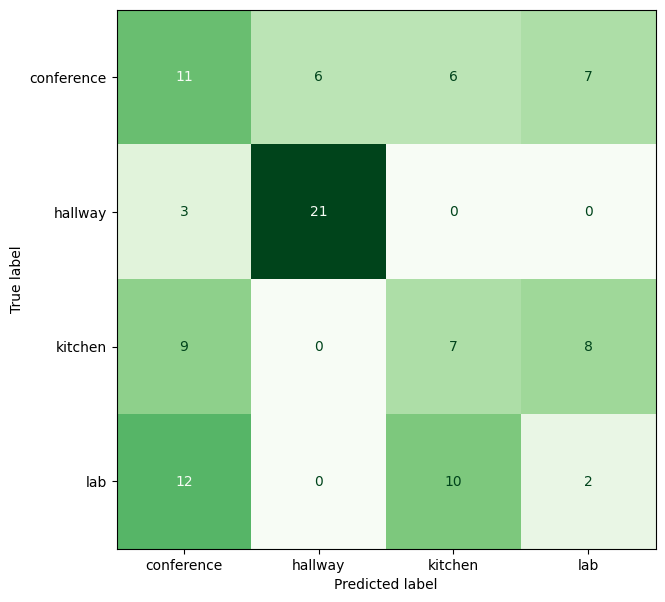

In [4]:
# ── Cell 4: Random Forest with Leave-One-Location-Out CV ─────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the shortlisted features
model_ready = pd.read_csv("spatial_seer_model_ready.csv")
feature_cols = [c for c in model_ready.columns if c not in META_COLS]

X = model_ready[feature_cols].values
room_enc = LabelEncoder().fit(model_ready["room_label"])
y = room_enc.transform(model_ready["room_label"])
groups = model_ready["location"].values

print(f"Feature matrix: {X.shape}")
print(f"Classes: {list(room_enc.classes_)}")
print(f"Groups (locations): {len(np.unique(groups))}")

# ── LOLO cross-validation ────────────────────────────────────────────────────
logo = LeaveOneGroupOut()
y_true_all, y_pred_all, fold_results = [], [], []
importance_accum = np.zeros(len(feature_cols))

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    held_out_loc = groups[test_idx][0]

    clf = RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    fold_results.append({
        "held_out": held_out_loc,
        "true_room": room_enc.inverse_transform(y_te)[0],
        "accuracy": acc,
        "n_test": len(y_te),
    })
    y_true_all.extend(y_te)
    y_pred_all.extend(y_pred)
    importance_accum += clf.feature_importances_

    print(f"  Held out: {held_out_loc:<30} room={fold_results[-1]['true_room']:<12} acc={acc:.4f}  (n={len(y_te)})")

# ── Aggregate results ────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)
overall_acc = accuracy_score(y_true_all, y_pred_all)

print(f"\n{'='*60}")
print(f"LOLO mean accuracy (per-fold avg) : {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
print(f"LOLO overall accuracy (all scans) : {overall_acc:.4f}")
print(f"{'='*60}\n")

print("Per-room-type breakdown:")
print(results_df.groupby("true_room")["accuracy"].agg(["mean", "std", "count"]).round(4))

print("\nWorst-performing locations:")
print(results_df.sort_values("accuracy").head(5)[["held_out", "true_room", "accuracy"]].to_string(index=False))

# ── Classification report ────────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=room_enc.classes_))

# ── Confusion matrix (matching your earlier orange/blue/purple scheme — green here) ─
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_true_all, y_pred_all),
    display_labels=room_enc.classes_,
)
disp.plot(ax=ax, colorbar=False, cmap="Greens")
style_confusion_matrix(disp, ax, "Room Type — Random Forest LOLO CV")
plt.tight_layout()
plt.show()

Running LOLO separately for noise levels: [np.int64(0), np.int64(1), np.int64(2)]

NOISE LEVEL 0
Scans: 34  |  Locations: 17  |  Classes: 4

Overall accuracy : 0.3529
Per-fold mean    : 0.3529 ± 0.4244

Per-room-type:
             mean     std  count
true_room                       
conference  0.100  0.2236      5
hallway     0.625  0.4787      4
kitchen     0.250  0.2887      4
lab         0.500  0.5774      4

Classification Report:
              precision    recall  f1-score   support

  conference       0.09      0.10      0.10        10
     hallway       0.71      0.62      0.67         8
     kitchen       0.33      0.25      0.29         8
         lab       0.40      0.50      0.44         8

    accuracy                           0.35        34
   macro avg       0.38      0.37      0.37        34
weighted avg       0.37      0.35      0.36        34


NOISE LEVEL 1
Scans: 34  |  Locations: 17  |  Classes: 4

Overall accuracy : 0.3824
Per-fold mean    : 0.3824 ± 0.4851

Per-

NameError: name 'style_confusion_matrix' is not defined

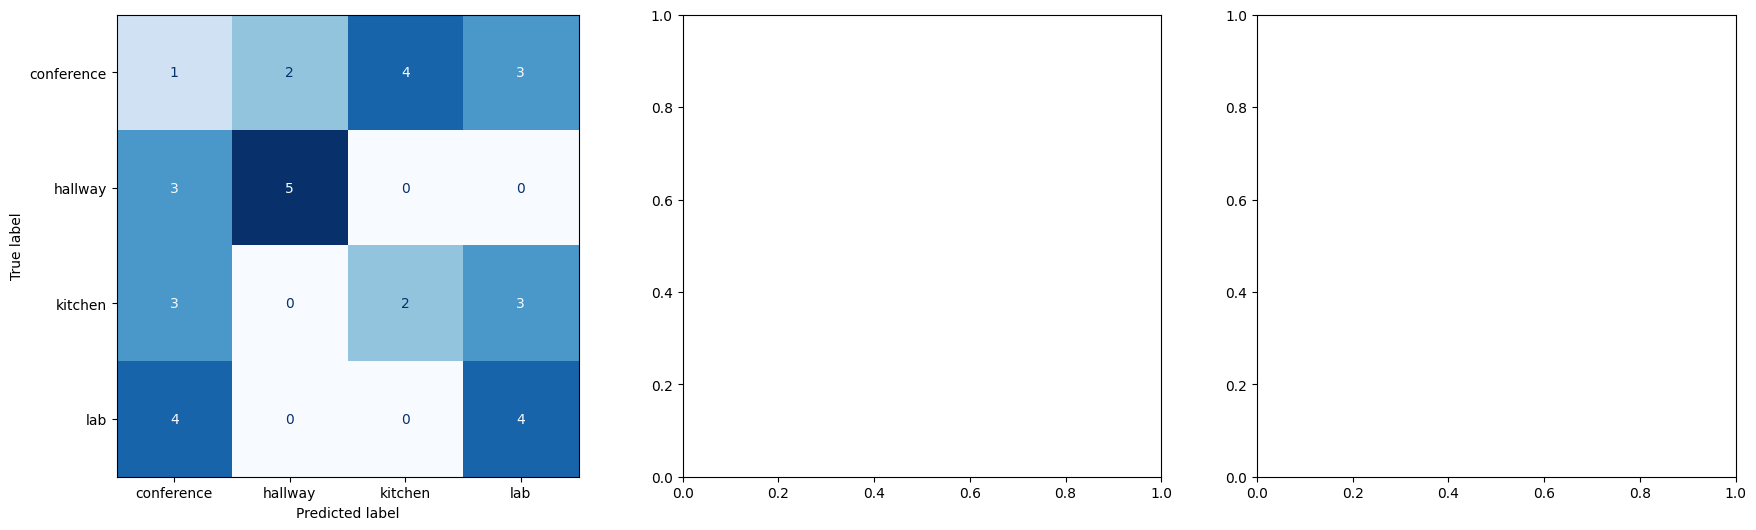

In [5]:
# ── Cell 5: Random Forest LOLO — Stratified by Noise Level ───────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

model_ready = pd.read_csv("spatial_seer_model_ready.csv")
feature_cols = [c for c in model_ready.columns if c not in META_COLS]
room_enc = LabelEncoder().fit(model_ready["room_label"])

noise_levels = sorted(model_ready["noise_type"].unique())
print(f"Running LOLO separately for noise levels: {noise_levels}\n")

summary_rows = []
all_fold_results = {}   # keep per-noise fold results for later inspection
all_predictions  = {}   # keep per-noise y_true/y_pred for confusion matrices

for noise in noise_levels:
    print(f"{'='*70}")
    print(f"NOISE LEVEL {noise}")
    print(f"{'='*70}")

    subset = model_ready[model_ready["noise_type"] == noise].reset_index(drop=True)
    X = subset[feature_cols].values
    y = room_enc.transform(subset["room_label"])
    groups = subset["location"].values

    print(f"Scans: {len(subset)}  |  Locations: {len(np.unique(groups))}  |  Classes: {len(np.unique(y))}")

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all, fold_results = [], [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        held_out_loc = groups[test_idx][0]

        clf = RandomForestClassifier(
            n_estimators=500,
            max_features="sqrt",
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)

        acc = accuracy_score(y_te, y_pred)
        fold_results.append({
            "held_out":   held_out_loc,
            "true_room":  room_enc.inverse_transform(y_te)[0],
            "accuracy":   acc,
            "n_test":     len(y_te),
        })
        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)

    results_df = pd.DataFrame(fold_results)
    overall_acc = accuracy_score(y_true_all, y_pred_all)

    print(f"\nOverall accuracy : {overall_acc:.4f}")
    print(f"Per-fold mean    : {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
    print(f"\nPer-room-type:")
    print(results_df.groupby("true_room")["accuracy"].agg(["mean", "std", "count"]).round(4))
    print(f"\nClassification Report:")
    print(classification_report(y_true_all, y_pred_all, target_names=room_enc.classes_, zero_division=0))

    # Track per-class recall for the summary table
    per_class = {}
    for i, cls in enumerate(room_enc.classes_):
        mask = np.array(y_true_all) == i
        if mask.sum() > 0:
            per_class[cls] = accuracy_score(np.array(y_true_all)[mask], np.array(y_pred_all)[mask])
        else:
            per_class[cls] = np.nan

    summary_rows.append({
        "noise_level":   noise,
        "n_scans":       len(subset),
        "overall_acc":   overall_acc,
        **{f"{cls}_recall": per_class[cls] for cls in room_enc.classes_},
    })
    all_fold_results[noise] = results_df
    all_predictions[noise]  = (y_true_all, y_pred_all)
    print()

# ── Summary table across noise levels ────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
print(f"\n{'='*70}")
print("SUMMARY — LOLO accuracy by noise level")
print(f"{'='*70}")
print(summary_df.to_string(index=False))

summary_df.to_csv("rf_lolo_by_noise_summary.csv", index=False)

# ── Side-by-side confusion matrices ──────────────────────────────────────────
cmaps = ["Blues", "Purples", "Oranges"]
fig, axes = plt.subplots(1, len(noise_levels), figsize=(7 * len(noise_levels), 6))
if len(noise_levels) == 1:
    axes = [axes]

for ax, noise, cmap in zip(axes, noise_levels, cmaps):
    y_true_all, y_pred_all = all_predictions[noise]
    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(len(room_enc.classes_)))
    disp = ConfusionMatrixDisplay(cm, display_labels=room_enc.classes_)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    style_confusion_matrix(disp, ax, f"Noise {noise}  (acc={accuracy_score(y_true_all, y_pred_all):.3f})")

plt.tight_layout()
plt.show()

Using ALL 1807 aggregate features
Running LOLO separately for noise levels: [np.int64(0), np.int64(1), np.int64(2)]

NOISE LEVEL 0
Scans: 34  |  Locations: 17  |  Features: 1807

Overall accuracy : 0.3529
Per-fold mean    : 0.3529 ± 0.3859

Per-room-type:
             mean     std  count
true_room                       
conference  0.100  0.2236      5
hallway     0.625  0.4787      4
kitchen     0.250  0.2887      4
lab         0.500  0.4082      4

Classification Report:
              precision    recall  f1-score   support

  conference       0.10      0.10      0.10        10
     hallway       0.62      0.62      0.62         8
     kitchen       0.25      0.25      0.25         8
         lab       0.50      0.50      0.50         8

    accuracy                           0.35        34
   macro avg       0.37      0.37      0.37        34
weighted avg       0.35      0.35      0.35        34


NOISE LEVEL 1
Scans: 34  |  Locations: 17  |  Features: 1807

Overall accuracy : 0.323

NameError: name 'style_confusion_matrix' is not defined

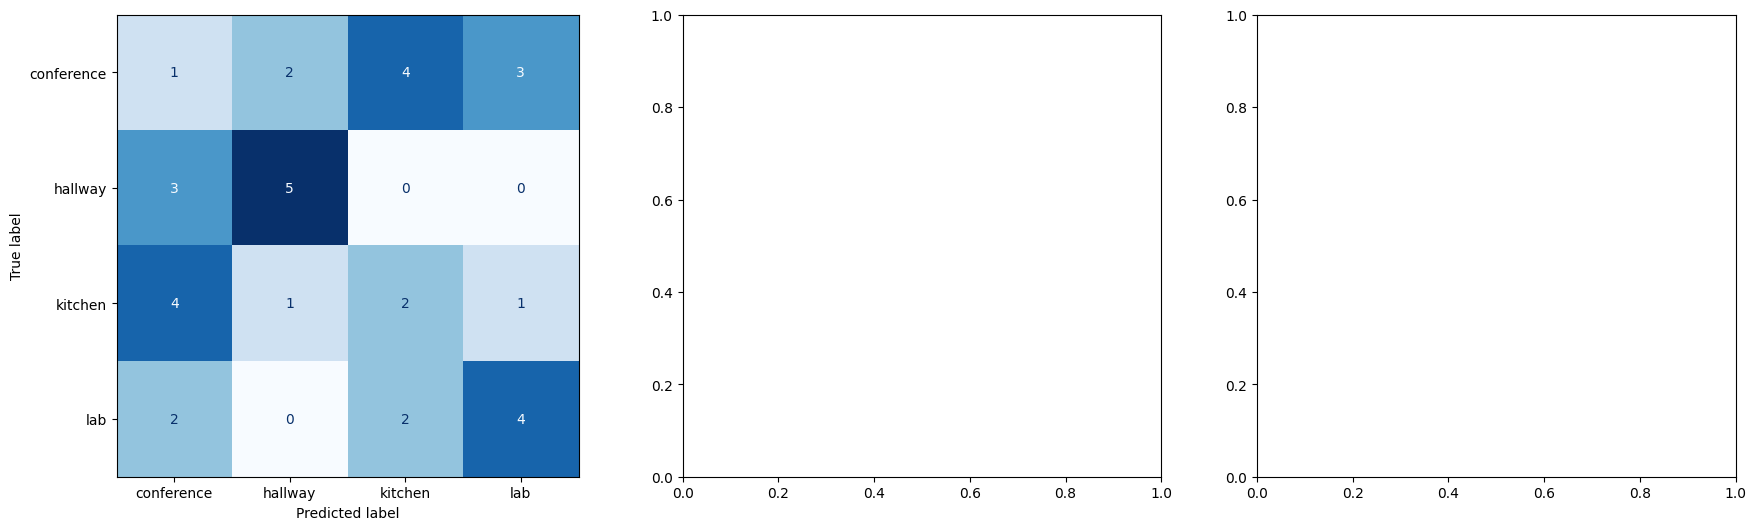

In [6]:
# ── Cell 6: Random Forest LOLO — All Features, Stratified by Noise Level ─────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the FULL feature matrix this time
features_df = pd.read_csv("spatial_seer_features.csv")
feature_cols = [c for c in features_df.columns if c not in META_COLS]
room_enc = LabelEncoder().fit(features_df["room_label"])

print(f"Using ALL {len(feature_cols)} aggregate features")

noise_levels = sorted(features_df["noise_type"].unique())
print(f"Running LOLO separately for noise levels: {noise_levels}\n")

summary_rows = []
all_fold_results = {}
all_predictions  = {}

for noise in noise_levels:
    print(f"{'='*70}")
    print(f"NOISE LEVEL {noise}")
    print(f"{'='*70}")

    subset = features_df[features_df["noise_type"] == noise].reset_index(drop=True)
    X = subset[feature_cols].values
    y = room_enc.transform(subset["room_label"])
    groups = subset["location"].values

    print(f"Scans: {len(subset)}  |  Locations: {len(np.unique(groups))}  |  Features: {X.shape[1]}")

    logo = LeaveOneGroupOut()
    y_true_all, y_pred_all, fold_results = [], [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        held_out_loc = groups[test_idx][0]

        clf = RandomForestClassifier(
            n_estimators=500,
            max_features="sqrt",
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)

        acc = accuracy_score(y_te, y_pred)
        fold_results.append({
            "held_out":   held_out_loc,
            "true_room":  room_enc.inverse_transform(y_te)[0],
            "accuracy":   acc,
            "n_test":     len(y_te),
        })
        y_true_all.extend(y_te)
        y_pred_all.extend(y_pred)

    results_df = pd.DataFrame(fold_results)
    overall_acc = accuracy_score(y_true_all, y_pred_all)

    print(f"\nOverall accuracy : {overall_acc:.4f}")
    print(f"Per-fold mean    : {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
    print(f"\nPer-room-type:")
    print(results_df.groupby("true_room")["accuracy"].agg(["mean", "std", "count"]).round(4))
    print(f"\nClassification Report:")
    print(classification_report(y_true_all, y_pred_all, target_names=room_enc.classes_, zero_division=0))

    per_class = {}
    for i, cls in enumerate(room_enc.classes_):
        mask = np.array(y_true_all) == i
        if mask.sum() > 0:
            per_class[cls] = accuracy_score(np.array(y_true_all)[mask], np.array(y_pred_all)[mask])
        else:
            per_class[cls] = np.nan

    summary_rows.append({
        "noise_level":   noise,
        "n_scans":       len(subset),
        "overall_acc":   overall_acc,
        **{f"{cls}_recall": per_class[cls] for cls in room_enc.classes_},
    })
    all_fold_results[noise] = results_df
    all_predictions[noise]  = (y_true_all, y_pred_all)
    print()

# ── Summary table ────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
print(f"\n{'='*70}")
print("SUMMARY — LOLO accuracy by noise level  (ALL FEATURES)")
print(f"{'='*70}")
print(summary_df.to_string(index=False))

summary_df.to_csv("rf_lolo_by_noise_summary_allfeatures.csv", index=False)

# ── Side-by-side confusion matrices ──────────────────────────────────────────
cmaps = ["Blues", "Purples", "Oranges"]
fig, axes = plt.subplots(1, len(noise_levels), figsize=(7 * len(noise_levels), 6))
if len(noise_levels) == 1:
    axes = [axes]

for ax, noise, cmap in zip(axes, noise_levels, cmaps):
    y_true_all, y_pred_all = all_predictions[noise]
    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(len(room_enc.classes_)))
    disp = ConfusionMatrixDisplay(cm, display_labels=room_enc.classes_)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    style_confusion_matrix(disp, ax, f"Noise {noise}  (acc={accuracy_score(y_true_all, y_pred_all):.3f})")

plt.tight_layout()
plt.show()